In [34]:
%load_ext autoreload
%autoreload 2

import argparse
from tqdm import tqdm

import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from optim_utils import *
from io_utils import *

from diffusers import DDIMScheduler, UNet2DConditionModel, StableDiffusionPipeline
from types import SimpleNamespace
from register_attention_control import register_attention_control
from controller import *

args = {
    "image_length": 512,
    "model_version" : 1,
    "unet_id": None,
    "with_tracking": False,
    "num_images_per_prompt": 4,
    "num_inference_steps": 50,
    "dtype" : torch.float16,
}
args = SimpleNamespace(**args)
if args.model_version == 1:
    args.model_id = "CompVis/stable-diffusion-v1-4"
elif args.model_version == 2:
    args.model_id = "Manojb/stable-diffusion-2-1-base"
else:
    raise ValueError(f"model_version!")
device = "cuda" if torch.cuda.is_available() else "cpu"

if args.unet_id is not None:
    unet = UNet2DConditionModel.from_pretrained(
        args.unet_id, torch_dtype=args.dtype
    )
    pipe = StableDiffusionPipeline.from_pretrained(
        args.model_id,
        unet=unet,
        torch_dtype=args.dtype,
        safety_checker=None,
        requires_safety_checker=False,
    )
else:
    pipe = StableDiffusionPipeline.from_pretrained(
        args.model_id,
        torch_dtype=args.dtype,
        safety_checker=None,
        requires_safety_checker=False,
    )
pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)
pipe = pipe.to(device)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [35]:
def sigma_from_scheduler(pipe, t, dtype, device):
    alphas_cumprod = pipe.scheduler.alphas_cumprod.to(device=device, dtype=dtype)
    alpha_bar = alphas_cumprod[t.long()]
    return torch.sqrt(1 - alpha_bar)

def rademacher_like(x):
    return torch.empty_like(x).bernoulli_(0.5).mul_(2).sub_(1)

def hutchinson_diag_from_output(eps, z_input, t, k=16):
    """
    이미 계산된 epsilon output으로부터 Hessian diagonal 계산
    
    Args:
        eps: UNet의 epsilon 출력 (gradient tracking 되어야 함)
        z_input: 입력 latent (requires_grad=True 여야 함)
        t: timestep
        k: Hutchinson estimator의 샘플 수
    
    Returns:
        diag: Hessian의 diagonal 근사값
    """
    sigma = sigma_from_scheduler(pipe, t, z_input.dtype, eps.device)
    s = -eps / sigma
    
    diag = torch.zeros_like(z_input)
    for _ in range(k):
        v = rademacher_like(z_input)
        dot = (s * v).sum()
        (jtv,) = torch.autograd.grad(dot, z_input, retain_graph=True, create_graph=False)
        diag += v * jtv
    
    diag /= float(k)
    return diag.detach()

def cov_from_hessain(pipe, diag_h, t):
    alpha_bar = pipe.scheduler.alphas_cumprod[t]
    sigma_sq = 1 - alpha_bar
    print(f"alpha_bar: {alpha_bar}, sigma_sq: {sigma_sq}")
    return ((sigma_sq ** 2) * diag_h + sigma_sq) / alpha_bar



In [36]:
def plot_norm_graph(t_list, per_image_norm_list, avg_norm_list, title, ylabel="L2 norm"):
    """
    norm 그래프를 그리는 함수
    
    Args:
        t_list: timestep 리스트
        per_image_norm_list: 이미지별 norm 텐서 (steps, batch)
        avg_norm_list: 평균 norm 텐서 (steps,)
        title: 그래프 제목
        ylabel: y축 레이블
    """
    plt.figure(figsize=(10, 5))
    steps, batch = per_image_norm_list.shape
    
    # 각 이미지별 norm
    for img_idx in range(batch):
        plt.plot(
            t_list,
            per_image_norm_list[:, img_idx],
            linestyle='-',
            marker='o',
            alpha=0.4,
            label=f"Image {img_idx}"
        )
    
    # 평균 라인 (검은 굵은 선)
    plt.plot(t_list, avg_norm_list, linestyle='--', marker='o', 
             linewidth=1.5, color='black', label='Mean Norm', markersize=3)
    
    plt.xlabel("Diffusion timestep (original scale)")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.gca().invert_xaxis()  # 큰 timestep → 초기 단계
    plt.grid(True)
    plt.legend()
    plt.show()
    
def visualize_64x64(tensor, title=None, show_colorbar=True, upscale=False, target_size=512, cmap="viridis"):
    """
    64x64 텐서를 시각화하는 함수 (단일 또는 배치 지원)
    
    Args:
        tensor: shape (64, 64) 또는 (N, 64, 64), NumPy array or PyTorch tensor
        title: 그래프 제목 (단일) 또는 리스트 (배치)
        show_colorbar: colorbar 표시 여부
        upscale: True이면 512x512로 업스케일 (bilinear interpolation)
        target_size: upscale 시 목표 크기
    """
    # 텐서를 numpy로 변환
    if isinstance(tensor, torch.Tensor):
        tensor = tensor.detach().cpu()
        is_torch = True
    else:
        tensor = np.array(tensor)
        is_torch = False
    
    # 차원 체크 및 배치 처리
    if tensor.ndim == 2:
        # 단일 이미지: (64, 64) -> (1, 64, 64)
        tensor = tensor[np.newaxis, :, :] if not is_torch else tensor.unsqueeze(0)
        single_image = True
    elif tensor.ndim == 3:
        # 배치: (N, 64, 64)
        single_image = False
    else:
        raise ValueError(f"Expected shape (64, 64) or (N, 64, 64), got {tensor.shape}")
    
    num_images = tensor.shape[0]
    
    # Upscale 처리
    if upscale:
        if is_torch or isinstance(tensor, np.ndarray):
            # Torch 텐서로 변환 (upscale 용)
            if not is_torch:
                tensor_torch = torch.from_numpy(tensor).float()
            else:
                tensor_torch = tensor.float()
            
            # (N, 64, 64) -> (N, 1, 64, 64) -> upscale -> (N, 1, 512, 512) -> (N, 512, 512)
            tensor_torch = tensor_torch.unsqueeze(1)
            tensor_torch = F.interpolate(
                tensor_torch, 
                size=(target_size, target_size), 
                mode='bilinear', 
                align_corners=False
            )
            tensor = tensor_torch.squeeze(1).numpy()
        display_size = target_size
    else:
        if is_torch:
            tensor = tensor.numpy()
        display_size = 64
    
    # 시각화
    fig, axes = plt.subplots(1, num_images, figsize=(5 * num_images, 5))
    
    # 단일 이미지인 경우 axes를 리스트로 변환
    if num_images == 1:
        axes = [axes]
    
    # 공통 colorbar를 위한 vmin, vmax 계산
    if show_colorbar:
        vmin = tensor.min()
        #vmax = tensor.max()
        vmax = np.percentile(tensor, 99)
    
    # 첫 번째 이미지의 mappable 저장 (공통 colorbar용)
    first_im = None
    
    for idx in range(num_images):
        img = tensor[idx]
        
        if show_colorbar:
            im = axes[idx].imshow(img, cmap=cmap, interpolation="nearest", vmin=vmin, vmax=vmax)
            if first_im is None:
                first_im = im
        else:
            im = axes[idx].imshow(img, cmap=cmap, interpolation="nearest")
        
        axes[idx].axis("off")
        
        # 제목 설정
        if title is not None:
            if isinstance(title, list) and len(title) > idx:
                axes[idx].set_title(title[idx], fontsize=12)
            elif isinstance(title, str) and single_image:
                axes[idx].set_title(title, fontsize=12)
            elif isinstance(title, str):
                axes[idx].set_title(f"{title} - Image {idx}", fontsize=12)
        else:
            if not single_image:
                axes[idx].set_title(f"Image {idx}", fontsize=12)
    
    # 전체 제목
    size_str = f"{display_size}x{display_size}"
    if upscale and display_size != 64:
        size_str = f"{display_size}x{display_size} (upscaled from 64x64)"
    
    if title is not None and isinstance(title, str):
        fig.suptitle(f"{title} ({size_str})", fontsize=14, y=1.02)
    else:
        fig.suptitle(f"Visualization ({size_str})", fontsize=14, y=1.02)
    
    # subplot들을 왼쪽으로 조정하여 colorbar 공간 확보
    if show_colorbar and first_im is not None:
        plt.tight_layout(rect=[0, 0, 0.95, 1])
        # 전체 figure에 대한 colorbar 하나만 추가
        if isinstance(axes, np.ndarray):
            fig.colorbar(first_im, ax=axes.ravel().tolist(), fraction=0.015, pad=0.02)
        elif isinstance(axes, list):
            fig.colorbar(first_im, ax=axes, fraction=0.015, pad=0.02)
        else:
            fig.colorbar(first_im, ax=[axes], fraction=0.015, pad=0.02)
    else:
        plt.tight_layout()
    
    plt.show()

from scipy.stats import gaussian_kde
def plot_heatmap_distribution(heatmaps, prompt="", show_individual=True, log_scale=False):
    """
    히트맵 값들의 분포를 KDE로 간단하게 시각화
    
    Args:
        heatmaps: 히트맵 텐서들의 리스트 또는 배열 (각 이미지별)
        prompt: 프롬프트 텍스트
        show_individual: True면 각 이미지별 KDE도 표시, False면 전체만 표시
        timestep_start: 평균을 계산할 시작 timestep (None이면 처음부터)
        timestep_end: 평균을 계산할 끝 timestep (None이면 끝까지)
    """
    # 히트맵 값들을 numpy 배열로 변환
    if isinstance(heatmaps, torch.Tensor):
        if heatmaps.dim() == 3:  # (N, H, W)
            heatmaps = [heatmaps[i].cpu().numpy() for i in range(heatmaps.size(0))]
        elif heatmaps.dim() == 4:  # (T, N, H, W)
            heatmaps = heatmaps.sum(dim=1)  # 채널널축 평균
            heatmaps = [heatmaps[i].cpu().numpy() for i in range(heatmaps.size(0))]
    else:
        heatmaps = [h.cpu().numpy() if isinstance(h, torch.Tensor) else h for h in heatmaps]
    
    # 전체 히트맵 값들 수집
    all_values = []
    individual_values = []
    for i, hmap in enumerate(heatmaps):
        values = hmap.flatten()
        individual_values.append(values)
        all_values.extend(values)
    
    all_values = np.array(all_values)
    
    # 시각화
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # 색상 설정
    colors = plt.cm.Set2(np.linspace(0, 1, len(individual_values)))
    
    # KDE 계산 및 플롯
    x_range = np.linspace(all_values.min(), all_values.max(), 1000)
    
    # 개별 이미지 KDE (옵션) - 진하게 표시
    if show_individual and len(individual_values) <= 10:  # 너무 많으면 표시하지 않음
        for i, values in enumerate(individual_values):
            kde = gaussian_kde(values)
            density = kde(x_range)
            ax.plot(x_range, density, color=colors[i], alpha=0.9, linewidth=2, label=f'Image {i+1}')
    
    # 통계치 표시
    mean_val = np.mean(all_values)
    median_val = np.median(all_values)
    
    # 디버깅: 값 범위 확인
    print(f"[DEBUG] all_values stats:")
    print(f"  - min: {all_values.min():.6f}")
    print(f"  - max: {all_values.max():.6f}")
    print(f"  - mean: {mean_val:.6f}")
    print(f"  - median: {median_val:.6f}")
    print(f"  - 25th percentile: {np.percentile(all_values, 25):.6f}")
    print(f"  - 75th percentile: {np.percentile(all_values, 75):.6f}")
    
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Mean: {mean_val:.3f}')
    ax.axvline(median_val, color='green', linestyle='--', linewidth=2, alpha=0.7, label=f'Median: {median_val:.3f}')
    
    # 레이블 및 제목
    ax.set_xlabel('Heatmap Value' + (' (log scale)' if log_scale else ''), fontsize=13)
    ax.set_ylabel('Density', fontsize=13)
    ax.set_title(f'Heatmap Value Distribution (KDE)\n{prompt}', fontsize=14, pad=15)
    if log_scale:
        ax.set_xscale('log')  # x축을 로그 스케일로 설정
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # 통계 정보 텍스트
    stats_text = (
        f"n={len(all_values):,} | "
        f"μ={mean_val:.4f} | "
        f"σ={np.std(all_values):.4f} | "
        f"min={all_values.min():.4f} | "
        f"max={all_values.max():.4f}"
    )
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
            verticalalignment='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    plt.tight_layout()
    plt.show()
    #plt.close(fig)

In [37]:
# 샘플링 파라미터 설정
num_inference_steps = args.num_inference_steps
num_images_per_prompt = args.num_images_per_prompt
height = args.image_length
width = args.image_length

#target_step = 30
target_steps = [45,46,47,48,49]#[0, 10,20,30,40,49]
guidance_scale = 10.0#7.5
use_cfg = False
seed = 42
#prompt = "A small kitchen with some quirky art decorations."
prompt = "Designart Canada White Stained Glass Floral Design 29-in Round Metal Wall Art"#"Designart Canada White Stained Glass Floral Design 29-in Round Metal Wall Art"#"Lilah Gray Area Rug By Andover Mills."#
#prompt = "Elon Musk is giving a speech"
#"Signature Purple Ombre Sugar Skull and Rose Bedding"
#"Emma Watson to play Belle in Disney's <i>Beauty and the Beast</i>"
#"Lilah Gray Area Rug By Andover Mills."
#"Designart Canada White Stained Glass Floral Design 29-in Round Metal Wall Art"
#"Designart Canada White Stained Glass Floral Design 29-in Round Metal Wall Art"
# #"Mothers influence on her young hippo"
#"Full body U-Zip main opening - Full body U-Zip main opening on front of bag for easy unloading when you get to camp"
#"Designart Canada White Stained Glass Floral Design 29-in Round Metal Wall Art"
#"Sony Boss Confirms Bloodborne Expansion is Coming"
#"Captain Marvel Exclusive Ccxp Poster Released Online By Marvel"
#"Lilah Gray Area Rug by Andover Mills"
#"Designart Canada White Stained Glass Floral Design 29-in Round Metal Wall Art"
# #"Plymouth Curtain Panel featuring diamond_x_blue_gray by boxwood_press"
#"Shaw Floors SFA Awesome 4 Linen 00104_E0741"#
#"Designart Multicolor Optical Fiber Lighting LargeAbstract Canvas Wall Art - 5 Panels"
#"I Am A Dreamer Blue White Circle Throw Pillow"#"Designart Yellow Trees and Fallen Leaves Modern Forest Canvas Art - 4 Panels"#"Shaw Floors SFA Awesome 4 Linen 00104_E0741"
#"The No Limits Business Woman Podcast"
#"Designart Canada White Stained Glass Floral Design 29-in Round Metal Wall Art"
#"Designart Pink Fractal Abstract Illustration Abstract CanvasWall Art - 4 Panels"
#"35 hundred titles up the < linkbook moon jennifer doubtfire works its ia sequel"
# prompt = "Daniel Radcliffe Dons a Beard and Saggy Jeans in Trailer for BBC GTA Miniseries <i>The Gamechangers</i>"
# prompt = "Kim kardashian"
negative_prompt = ""




In [38]:
# 1. 프롬프트 인코딩
text_inputs = pipe.tokenizer(
    prompt,
    padding="max_length",
    max_length=pipe.tokenizer.model_max_length,
    truncation=False,
    return_tensors="pt",
)
text_input_ids = text_inputs.input_ids.to(device)

# Conditional embeddings
prompt_embeds = pipe.text_encoder(text_input_ids)[0]
prompt_embeds = prompt_embeds.repeat(num_images_per_prompt, 1, 1)

# Unconditional embeddings (for classifier-free guidance)
uncond_tokens = pipe.tokenizer(
    negative_prompt if negative_prompt else "",
    padding="max_length",
    max_length=pipe.tokenizer.model_max_length,
    truncation=True,
    return_tensors="pt",
).input_ids.to(device)
negative_prompt_embeds = pipe.text_encoder(uncond_tokens)[0]
negative_prompt_embeds = negative_prompt_embeds.repeat(num_images_per_prompt, 1, 1)

# Concatenate for standard CFG: [uncond, text]
prompt_embeds_combined = torch.cat([negative_prompt_embeds, prompt_embeds])

print(f"Prompt embeddings shape: {prompt_embeds.shape}")
print(f"Combined embeddings shape (uncond + text): {prompt_embeds_combined.shape}")

# 2. 스케줄러 설정
pipe.scheduler.set_timesteps(num_inference_steps, device=device)
timesteps = pipe.scheduler.timesteps


Prompt embeddings shape: torch.Size([4, 77, 768])
Combined embeddings shape (uncond + text): torch.Size([8, 77, 768])


# Diag(H)

Initial latent shape: torch.Size([4, 4, 64, 64])
Timesteps: torch.Size([50]), from 981 to 1


  0%|          | 0/50 [00:00<?, ?it/s]

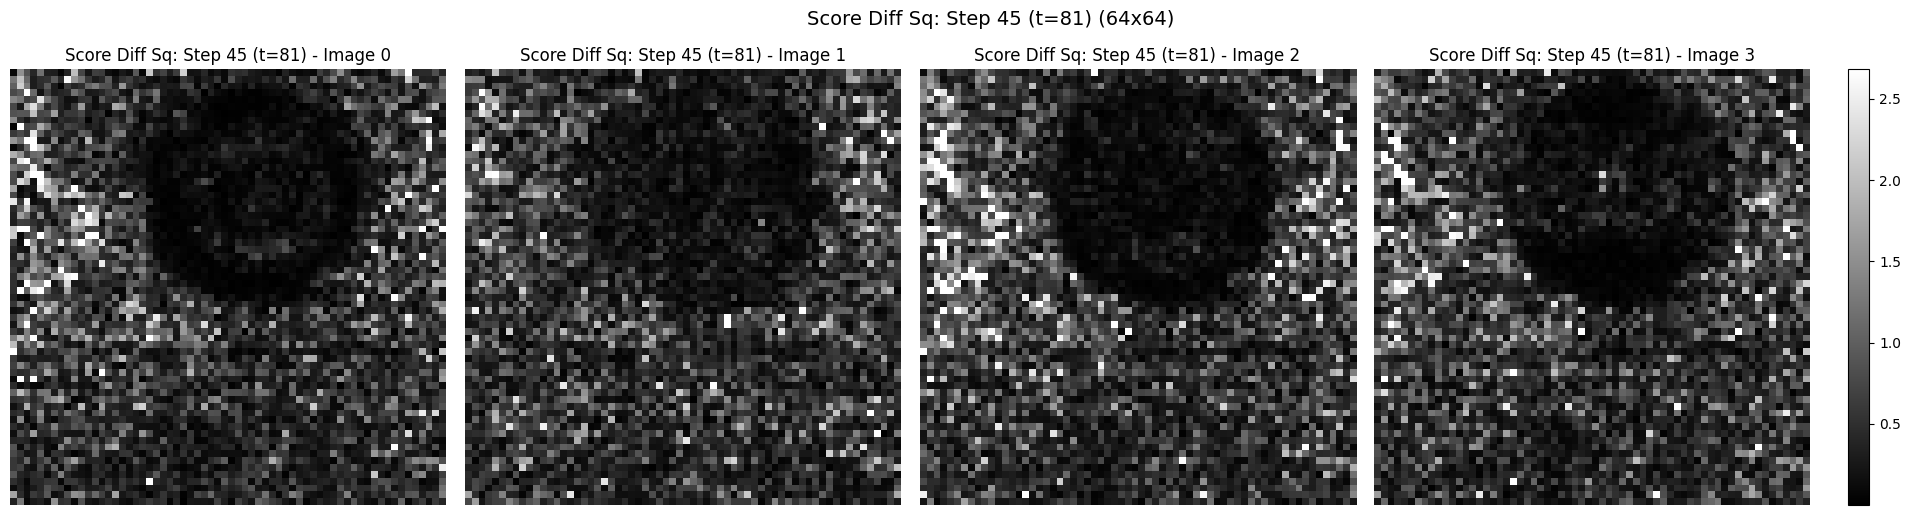

Step 45 (t=81):


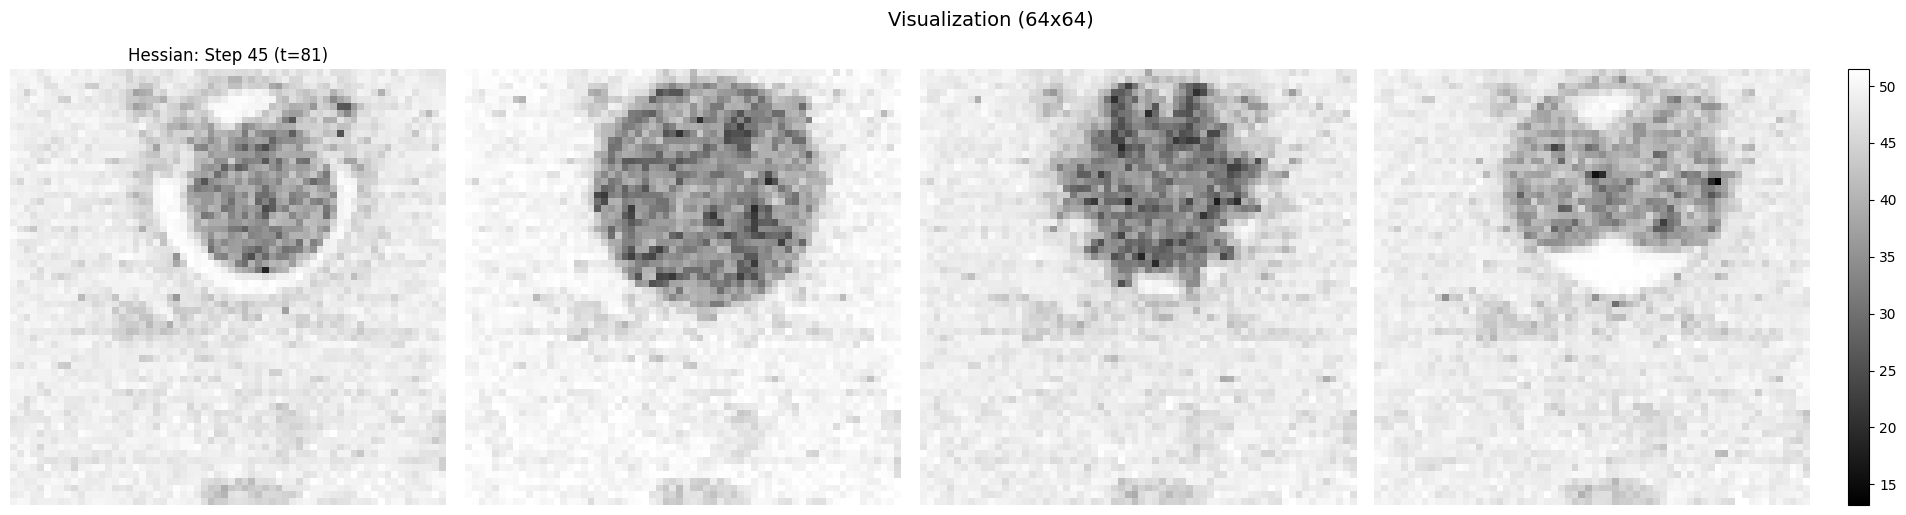

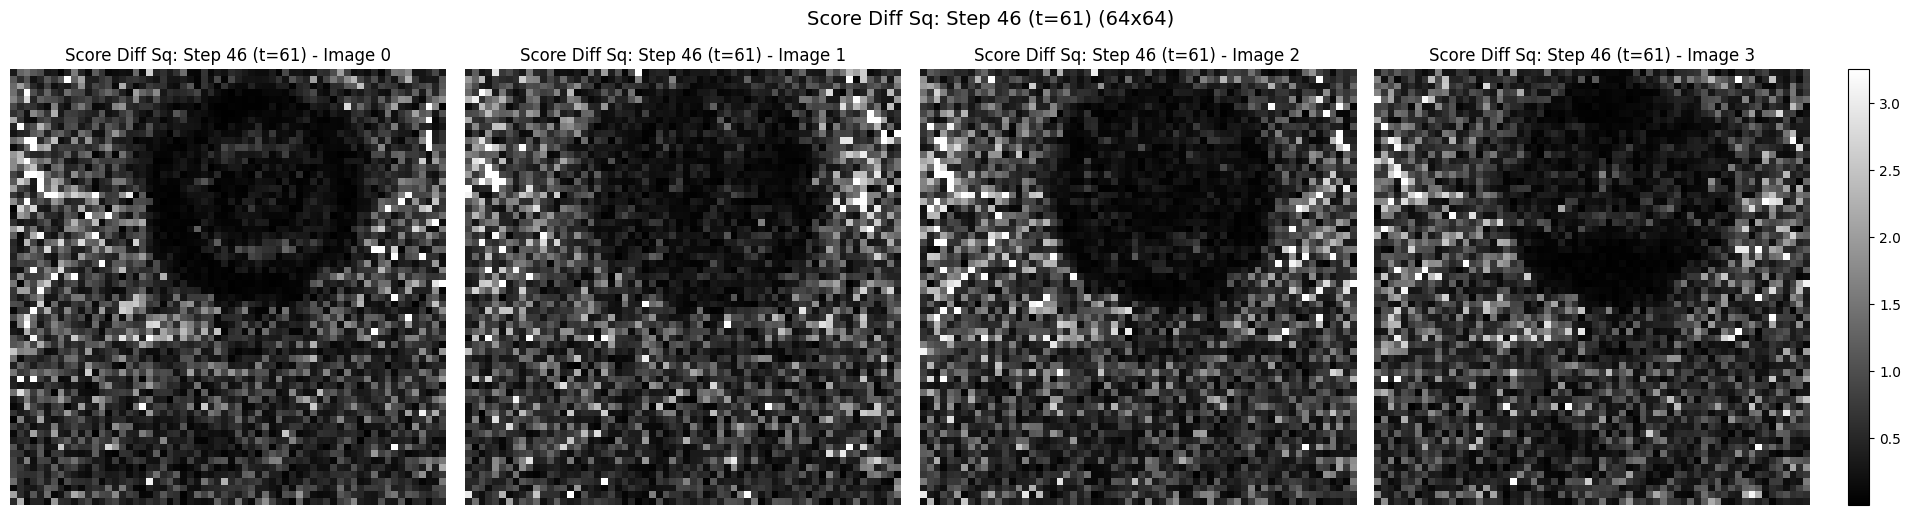

Step 46 (t=61):


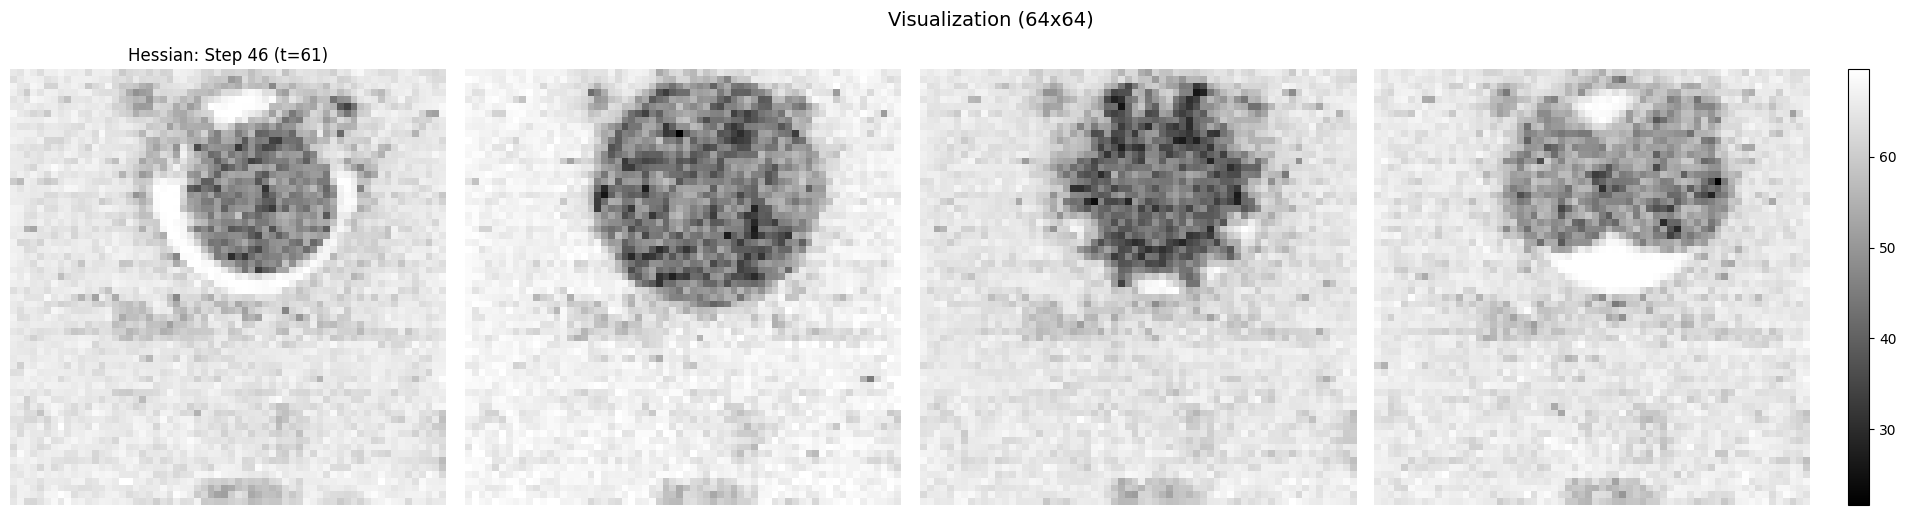

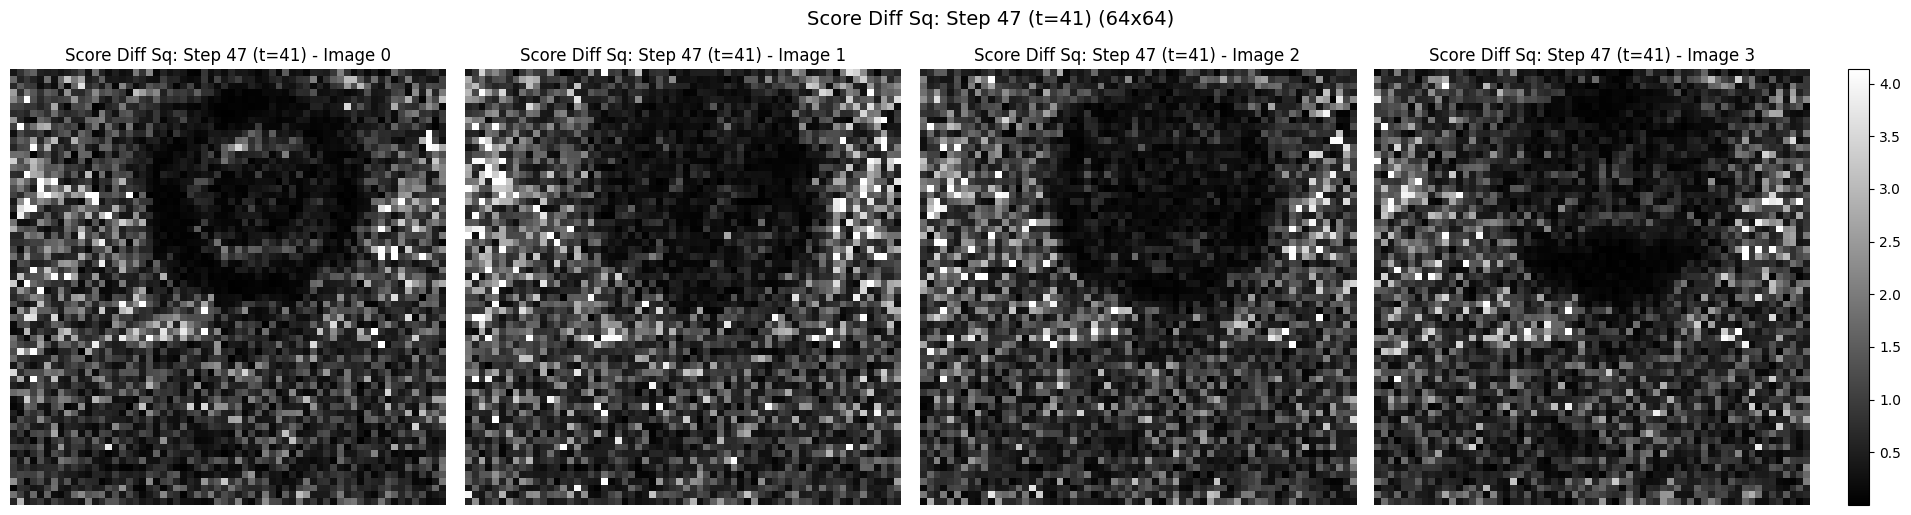

Step 47 (t=41):


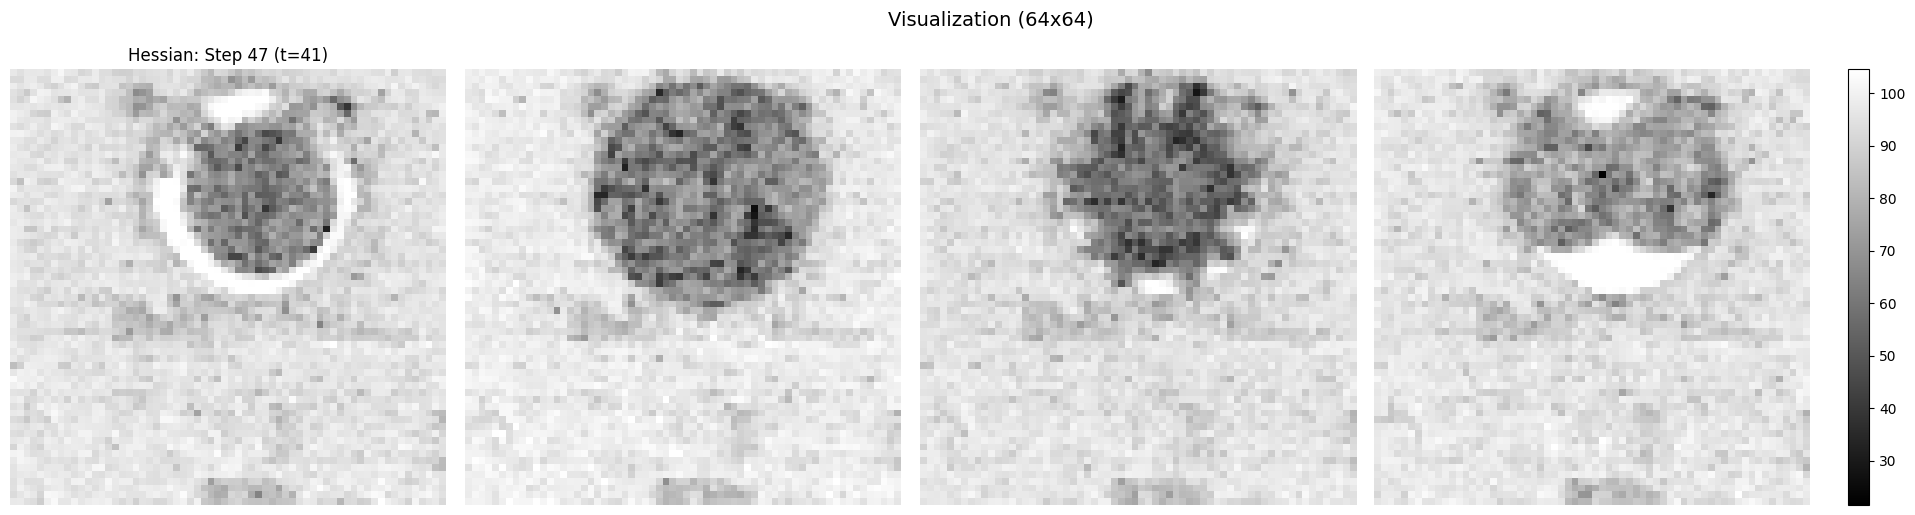

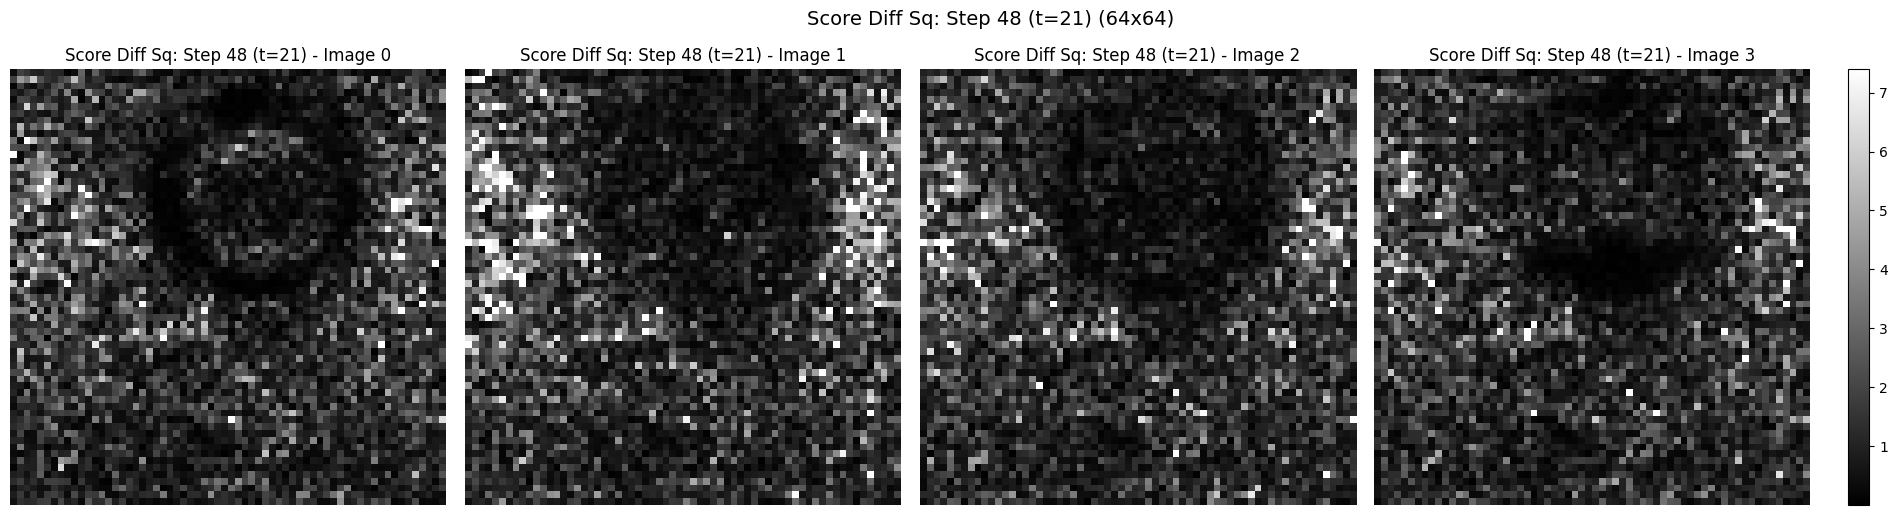

Step 48 (t=21):


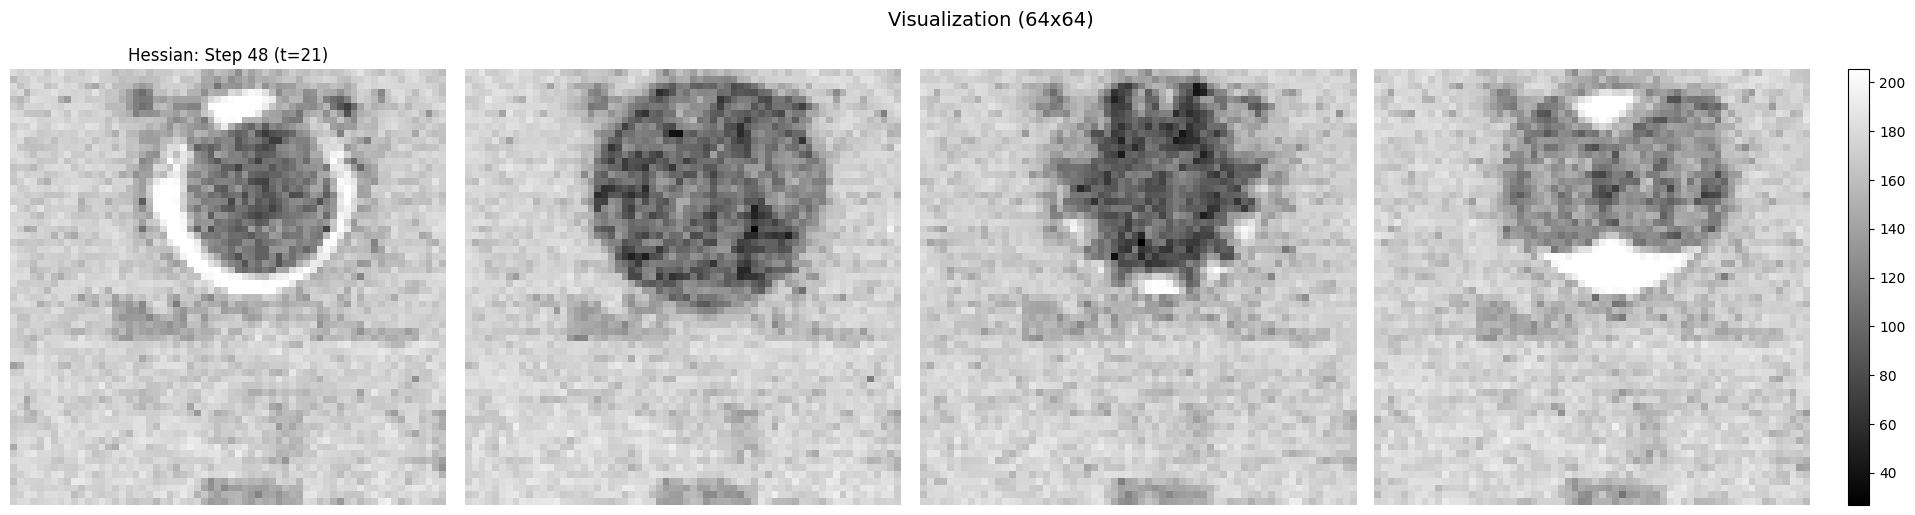

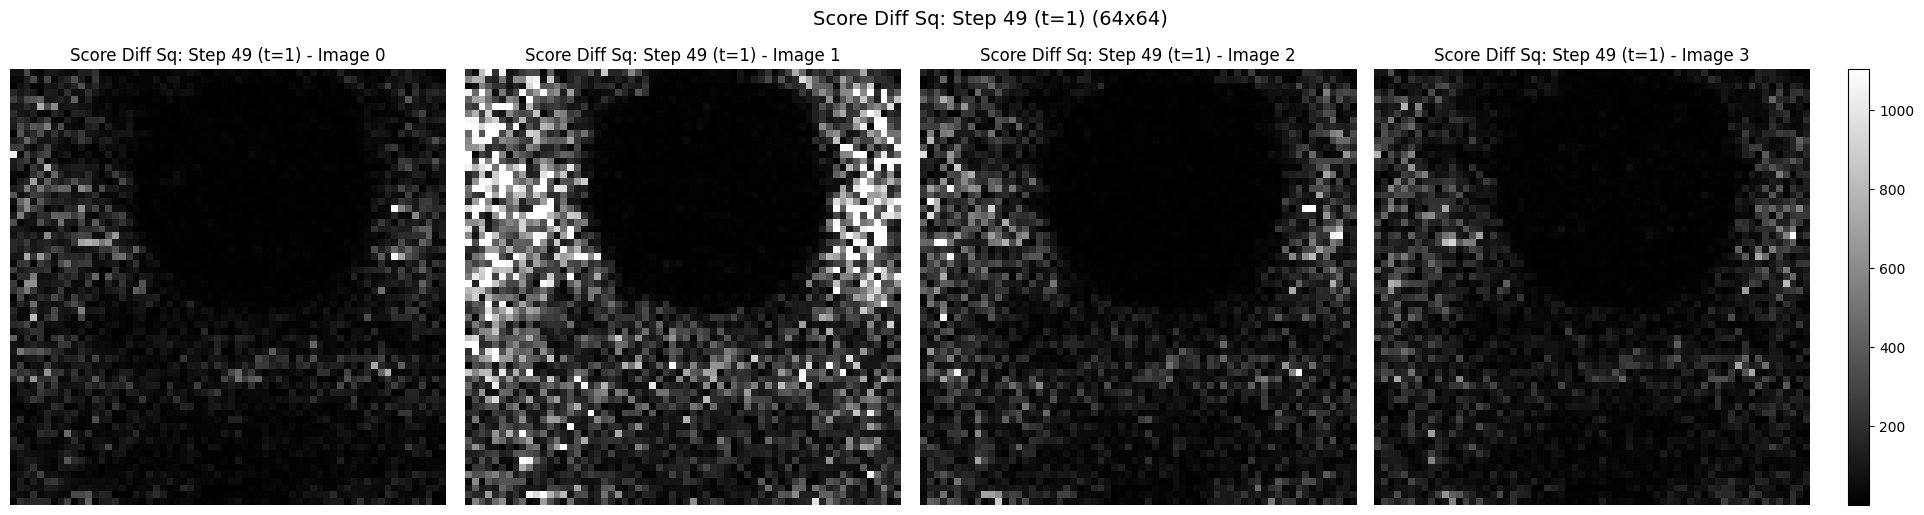

Step 49 (t=1):


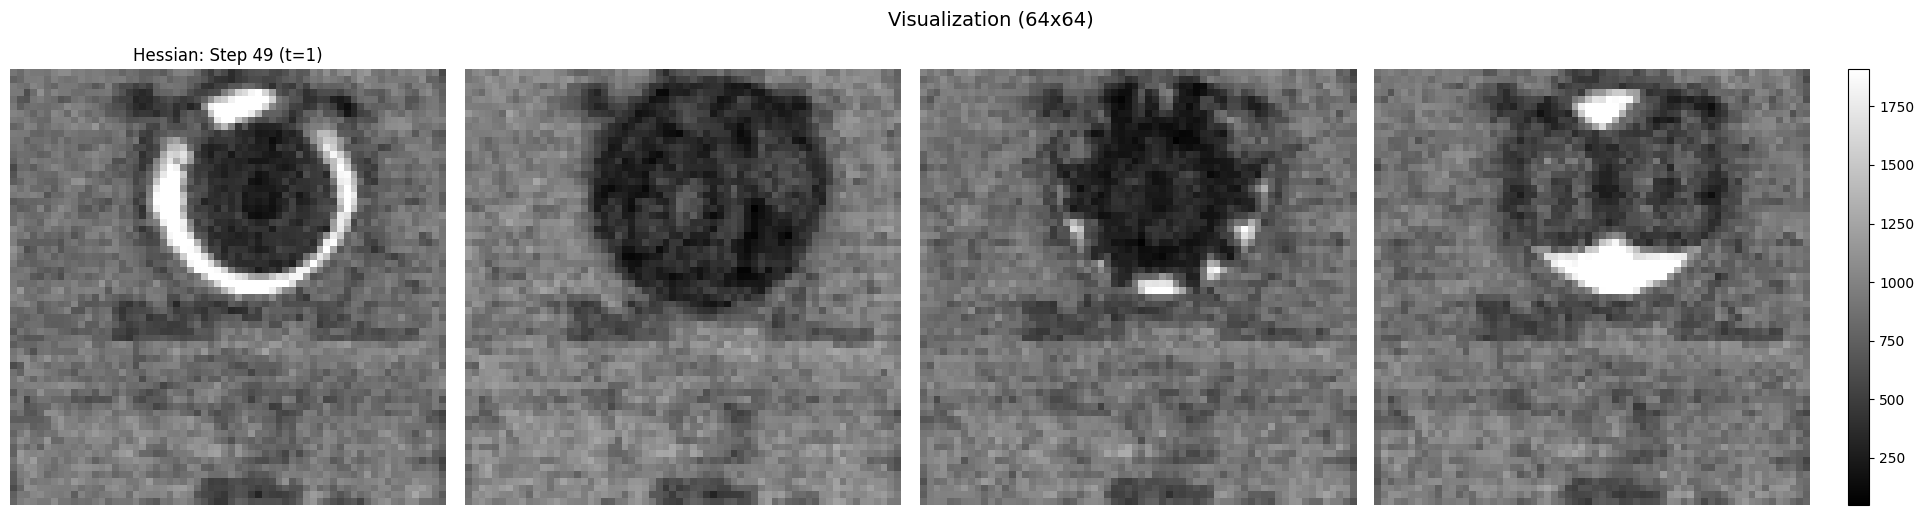

Generated images shape: (4, 512, 512, 3)
Image value range: [0.000, 1.000]


In [ ]:
%matplotlib inline
generator = torch.Generator(device=device).manual_seed(seed)
# 3. 초기 latent 생성 (랜덤 노이즈)
latent_channels = pipe.unet.config.in_channels
latent_height = height // pipe.vae_scale_factor
latent_width = width // pipe.vae_scale_factor

shape = (num_images_per_prompt, latent_channels, latent_height, latent_width)
latents = torch.randn(shape, generator=generator, device=device, dtype=prompt_embeds.dtype)

print(f"Initial latent shape: {latents.shape}")
# Latents에 초기 노이즈 스케일 적용
latents = latents * pipe.scheduler.init_noise_sigma

print(f"Timesteps: {timesteps.shape}, from {timesteps[0]} to {timesteps[-1]}")

# --- 기록용 리스트 ---
t_list = []
per_image_norm_text_vs_uncond = []  # text_vs_uncond norm
avg_norm_text_vs_uncond = []
diag_h_list = []  # Hessian diagonal 기록

diag_h = torch.ones_like(latents)
mask = torch.ones(latents.shape[0], 1, latents.shape[2], latents.shape[3], device=latents.device, dtype=latents.dtype)
# 4. Denoising loop with efficient Hessian computation
for i, t in enumerate(tqdm(timesteps)):
    # Hessian을 계산할 step인지 결정 (예: 매 10 step마다, 또는 특정 step에서만)
    compute_hessian = (i in target_steps)
    
    # ⚠️ Hessian 계산 시에는 attention 수집 비활성화 (gradient 충돌 방지)
    if compute_hessian:
        # Gradient tracking 활성화
        latents_with_grad = latents.detach().requires_grad_(True)
        latent_model_input = torch.cat([latents_with_grad] * 2, dim=0)
    else:

        # 일반 샘플링 (gradient 없이)
        latent_model_input = torch.cat([latents] * 2, dim=0)
    
    latent_model_input = pipe.scheduler.scale_model_input(latent_model_input, t)
    
    # UNet forward pass (한 번만!)
    if compute_hessian:
        # Gradient tracking 필요한 경우
        noise_pred = pipe.unet(
            latent_model_input,
            t,
            encoder_hidden_states=prompt_embeds_combined,
            return_dict=False,
        )[0]
    else:
        # Gradient 불필요한 경우
        with torch.no_grad():
            noise_pred = pipe.unet(
                latent_model_input,
                t,
                encoder_hidden_states=prompt_embeds_combined,
                return_dict=False,
            )[0]
    
    # Classifier-free guidance 분해
    noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
    text_vs_uncond = noise_pred_text - noise_pred_uncond
    
    # --- text_vs_uncond norm 계산 ---
    per_image_norms_vs = text_vs_uncond.flatten(1).norm(dim=1).detach()  # (batch,)
    avg_norm_vs = per_image_norms_vs.mean()
    
    # 기록
    t_list.append(t.item())
    per_image_norm_text_vs_uncond.append(per_image_norms_vs)
    avg_norm_text_vs_uncond.append(avg_norm_vs)
    eps_cfg = noise_pred_uncond + guidance_scale * text_vs_uncond# * diag_h / diag_h.mean(dim=(1,2,3), keep_dim= True)

    sigma = sigma_from_scheduler(pipe, t, latents.dtype, latents.device)
    score_diff = - text_vs_uncond / sigma
   
    if compute_hessian:
        score_diff_sq = (score_diff ** 2).sum(dim=1)
        visualize_64x64(score_diff_sq, title=f"Score Diff Sq: Step {i} (t={t.item()})", cmap="gray")
        #visualize_64x64(text_vs_uncond.norm(dim=1), title=f"Step {i} (t={t.item()})", cmap="gray")
        diag_h = hutchinson_diag_from_output(
            text_vs_uncond, #eps_cfg if use_cfg else noise_pred_text, 
            latents_with_grad, 
            t, 
            k=16
        )
        print(f"Step {i} (t={t.item()}):")
        
        # mask 계산
        # for j in range(num_images_per_prompt):
        #     sum_diag_h = diag_h[j].sum(dim=0)
        #     mask[j] = sum_diag_h > sum_diag_h.mean()
        #     print(f"mean(trace): {diag_h[j].mean().item():.4f}")
        #conditional_cov = cov_from_hessain(pipe, diag_h, t)
        # 4개 이미지를 한 figure에 2x2로 시각화
        summed_h = -diag_h.sum(dim=1)  # (N, 64, 64)
        summed_h = summed_h.relu()
        #mean_vals_h = summed_h.mean(dim=(1,2))  # (N,)
        titles_h = [f"Hessian: Step {i} (t={t.item()})"]
        visualize_64x64(summed_h, title=titles_h, cmap="gray")
        #plot_heatmap_distribution(-diag_h, prompt=prompt, show_individual=True)
        #summed_cov = conditional_cov.sum(dim=1)  # (N, 64, 64)
        #mean_vals_cov = summed_cov.mean(dim=(1,2))  # (N,)
        #titles_cov = [f"Cov: Step {i} (t={t.item()}), mean: {val.item():.4f}" for val in mean_vals_cov]
        #visualize_64x64(summed_cov, title=titles_cov, cmap="gray")
        #plot_heatmap_distribution(conditional_cov.sum(dim=1), prompt=prompt, show_individual=True)
        
        # --- text_vs_uncond norm의 gradient 계산 및 시각화 ---
        # text_vs_uncond의 L2 norm 계산
        if False:
            text_vs_uncond_norm = text_vs_uncond.flatten(1).norm(dim=1).sum()  # 전체 배치의 norm 합
            
            # latents_with_grad에 대한 gradient 계산
            grad_text_vs_uncond_norm = torch.autograd.grad(
                text_vs_uncond_norm, 
                latents_with_grad, 
                retain_graph=True, 
                create_graph=False
            )[0]
            
            # 채널 차원(dim=1)으로 합하기 (shape: [batch, 4, 64, 64] -> [batch, 64, 64])
            grad_text_vs_uncond_summed = grad_text_vs_uncond_norm.sum(dim=1)
            
            print(f"Gradient of text_vs_uncond norm - shape: {grad_text_vs_uncond_summed.shape}")
            print(f"Gradient stats - min: {grad_text_vs_uncond_summed.min().item():.4f}, "
                f"max: {grad_text_vs_uncond_summed.max().item():.4f}, "
                f"mean: {grad_text_vs_uncond_summed.mean().item():.4f}")
            
            # 시각화
            visualize_64x64(
                grad_text_vs_uncond_summed, 
                title=f"Gradient of text_vs_uncond norm (step {i}, t={t.item()})",
                show_colorbar=True, 
                upscale=False, 
                cmap="gray"
            )
    # Standard CFG: noise = uncond + guidance_scale * (text - uncond)
    
    # Hessian diagonal 계산 (이미 계산된 forward pass 재사용!)

        #diag_h_list.append(diag_h)    
    # scheduler step (gradient가 있으면 detach)
    latents = pipe.scheduler.step(
        eps_cfg.detach() if compute_hessian else eps_cfg, 
        t, 
        latents, 
        return_dict=False
    )[0]

# --- GPU → CPU 변환 (마지막에 한 번만) ---
per_image_norm_text_vs_uncond = torch.stack(per_image_norm_text_vs_uncond).cpu()  # (steps, batch)
avg_norm_text_vs_uncond = torch.stack(avg_norm_text_vs_uncond).cpu()              # (steps,)

# 5. VAE를 통해 latent를 이미지로 디코딩
latents = 1 / pipe.vae.config.scaling_factor * latents

with torch.no_grad():
    images = pipe.vae.decode(latents).sample

# 이미지를 [0, 1] 범위로 정규화
images = (images / 2 + 0.5).clamp(0, 1)

# [B, C, H, W] -> [B, H, W, C]로 변환 (numpy용)
images = images.cpu().permute(0, 2, 3, 1).float().numpy()

print(f"Generated images shape: {images.shape}")
print(f"Image value range: [{images.min():.3f}, {images.max():.3f}]")



# Bright Ending

In [40]:

target_step = 49
# Attention 수집을 위한 컨트롤러 생성
attention_controller = AttentionStore(target_step = target_step, model_version = args.model_version )

# enabled 플래그 추가 (Hessian 계산 중에는 비활성화)
attention_controller.enabled = True

# UNet에 attention control 등록
register_attention_control(pipe, attention_controller)
generator = torch.Generator(device=device).manual_seed(seed)
# 3. 초기 latent 생성 (랜덤 노이즈)
latent_channels = pipe.unet.config.in_channels
latent_height = height // pipe.vae_scale_factor
latent_width = width // pipe.vae_scale_factor

shape = (num_images_per_prompt, latent_channels, latent_height, latent_width)
latents = torch.randn(shape, generator=generator, device=device, dtype=prompt_embeds.dtype)

print(f"Initial latent shape: {latents.shape}")
# Latents에 초기 노이즈 스케일 적용
latents = latents * pipe.scheduler.init_noise_sigma

print(f"Timesteps: {timesteps.shape}, from {timesteps[0]} to {timesteps[-1]}")

print("Attention controller registered successfully!")
print(f"Controller type: {type(attention_controller)}")

# --- 기록용 리스트 ---
t_list = []
per_image_norm_text_vs_uncond = []  # text_vs_uncond norm
avg_norm_text_vs_uncond = []
# 4. Denoising loop with efficient Hessian computation
for i, t in enumerate(tqdm(timesteps)):
    #print(f"controller.step:{attention_controller.cur_step}")
    latent_model_input = torch.cat([latents] * 2, dim=0)
    
    latent_model_input = pipe.scheduler.scale_model_input(latent_model_input, t)
    

    with torch.no_grad():
        noise_pred = pipe.unet(
            latent_model_input,
            t,
            encoder_hidden_states=prompt_embeds_combined,
            return_dict=False,
        )[0]
    
    # Classifier-free guidance 분해
    noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
    text_vs_uncond = noise_pred_text - noise_pred_uncond
    
    # --- text_vs_uncond norm 계산 ---
    per_image_norms_vs = text_vs_uncond.flatten(1).norm(dim=1).detach()  # (batch,)
    avg_norm_vs = per_image_norms_vs.mean()
    
    # 기록
    t_list.append(t.item())
    per_image_norm_text_vs_uncond.append(per_image_norms_vs)
    avg_norm_text_vs_uncond.append(avg_norm_vs)

    # Standard CFG: noise = uncond + guidance_scale * (text - uncond)
    eps_cfg = noise_pred_uncond + guidance_scale * text_vs_uncond

    latents = pipe.scheduler.step(
        eps_cfg, 
        t, 
        latents, 
        return_dict=False
    )[0]

# --- GPU → CPU 변환 (마지막에 한 번만) ---
per_image_norm_text_vs_uncond = torch.stack(per_image_norm_text_vs_uncond).cpu()  # (steps, batch)
avg_norm_text_vs_uncond = torch.stack(avg_norm_text_vs_uncond).cpu()              # (steps,)

# 5. VAE를 통해 latent를 이미지로 디코딩
latents = 1 / pipe.vae.config.scaling_factor * latents

with torch.no_grad():
    images = pipe.vae.decode(latents).sample

# 이미지를 [0, 1] 범위로 정규화
images = (images / 2 + 0.5).clamp(0, 1)

# [B, C, H, W] -> [B, H, W, C]로 변환 (numpy용)
images = images.cpu().permute(0, 2, 3, 1).float().numpy()

print(f"Generated images shape: {images.shape}")
print(f"Image value range: [{images.min():.3f}, {images.max():.3f}]")



Initial latent shape: torch.Size([4, 4, 64, 64])
Timesteps: torch.Size([50]), from 981 to 1
Attention controller registered successfully!
Controller type: <class 'controller.AttentionStore'>


  0%|          | 0/50 [00:00<?, ?it/s]

Generated images shape: (4, 512, 512, 3)
Image value range: [0.000, 1.000]



Attention Collection Summary
attn_score:2


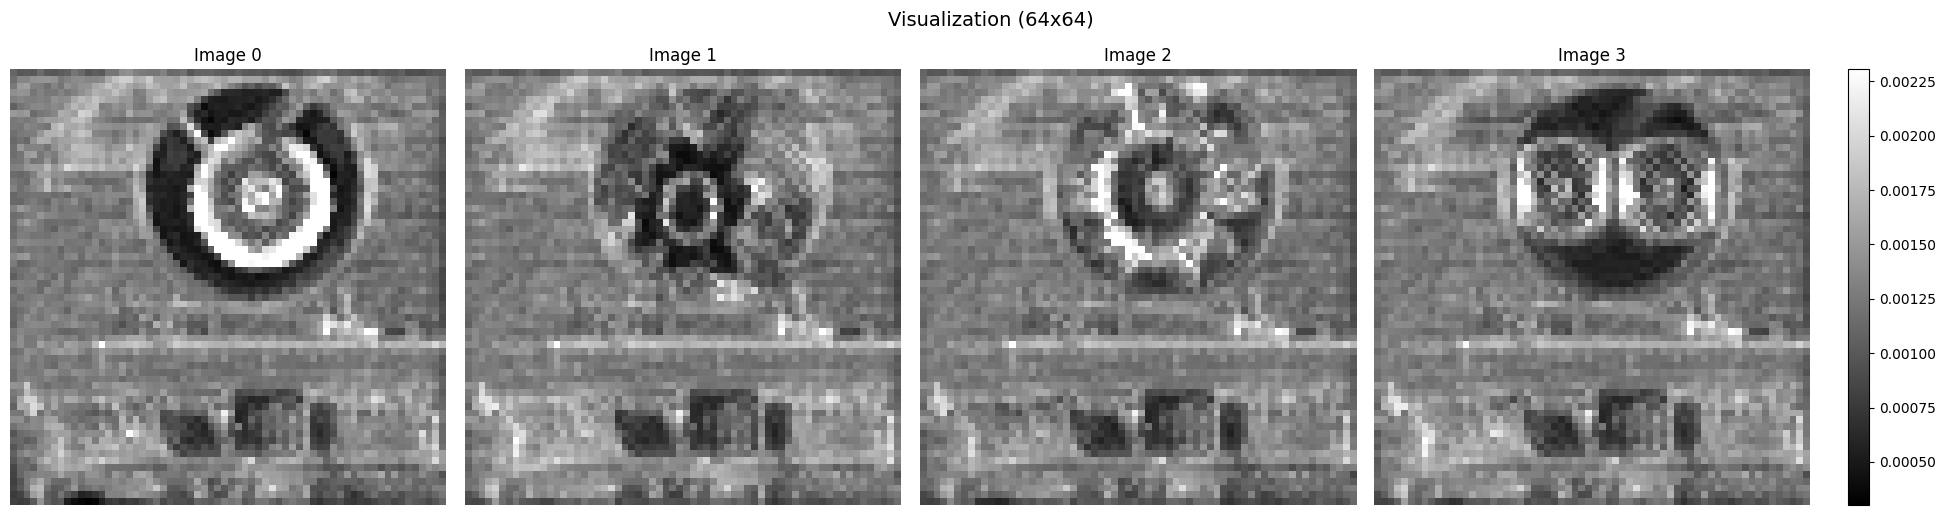

In [41]:
# ========== Attention 수집 및 Shape 확인 ==========
print("\n" + "="*60)
print("Attention Collection Summary")
print("="*60)
tokenizer = pipe.tokenizer
attn_score = [
    attn.cpu().numpy()
    for attn in attention_controller.attention_store["down_cross"]
]
print(f"attn_score:{len(attn_score)}")
token_len = min(len(tokenizer.encode(prompt)), attn_score[0].shape[-1])
#print("1: ",len(attn_score), attn_score[0].shape)
# 2, (4, 4096, 77) layer-wise mean
attn_score_aver = np.mean(attn_score, axis=0)
#print("2: ", attn_score_aver.shape)
# (4, 4096, 77) reshpae to image shape
attn_score_aver = attn_score_aver.reshape(args.num_images_per_prompt, 64, 64, 77)
#print("3: ", attn_score_aver.shape)
# (4, 64, 64, 77) select EOS toekn
attn_score_aver = attn_score_aver[:,:,:,token_len-1] 
#print("4: ", attn_score_aver.shape)
# (4, 64, 64) expand dims to (4, 1, 64, 64)
attn_score_aver = np.expand_dims(attn_score_aver, axis=1) 
#print("5: ", attn_score_aver.shape)
# (4,1,64,64)
attn_score_aver = torch.from_numpy(attn_score_aver).to(device)
#print("6: ", attn_score_aver.shape)
visualize_64x64(attn_score_aver.squeeze(1), title=None, show_colorbar=True, upscale=False, target_size=512, cmap="gray")
#visualize_64x64(attn_score_aver, )

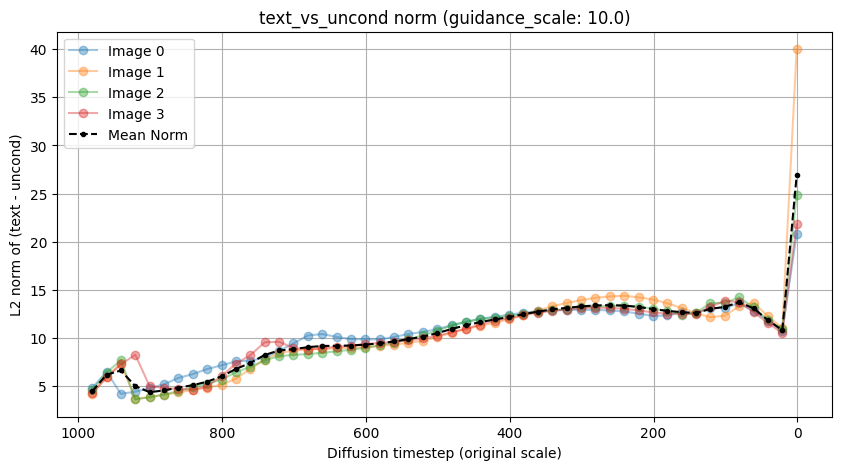

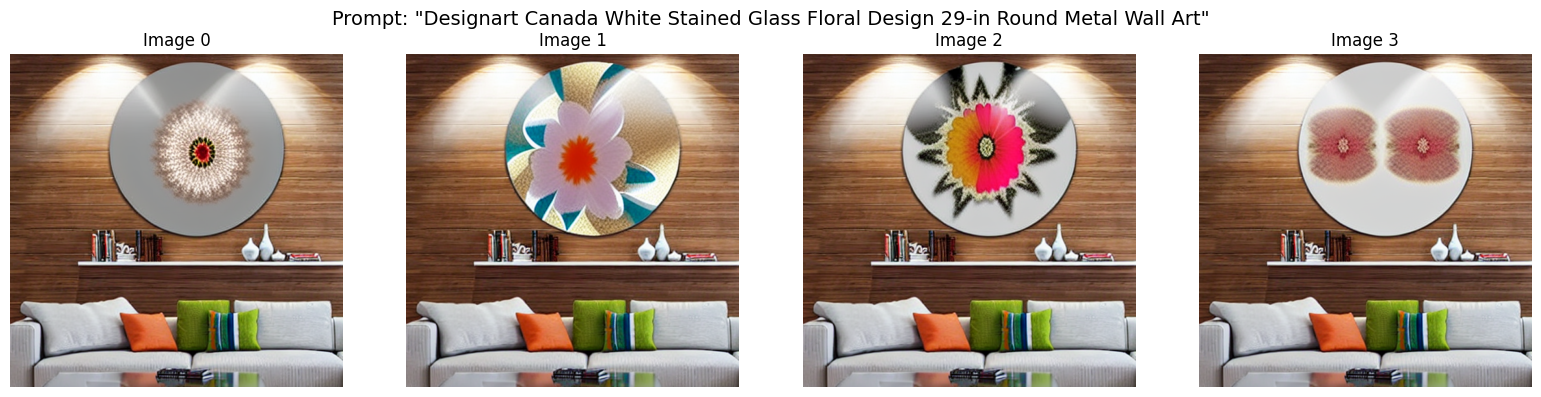

In [42]:
%matplotlib inline

# text_vs_uncond norm 그래프
plot_norm_graph(
    t_list, 
    per_image_norm_text_vs_uncond, 
    avg_norm_text_vs_uncond,
    title=f"text_vs_uncond norm (guidance_scale: {guidance_scale})",
    ylabel="L2 norm of (text - uncond)"
)

#=============================================================
fig, axes = plt.subplots(1, num_images_per_prompt, figsize=(4 * num_images_per_prompt, 4))
if num_images_per_prompt == 1:
    axes = [axes]

for idx, (ax, img) in enumerate(zip(axes, images)):
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'Image {idx}')

plt.suptitle(f'Prompt: "{prompt}"', fontsize=14, y=0.98)
plt.tight_layout()
plt.show()
